In [4]:
# %load /content/FLD_preprocess.py
import os
import random
from math import cos, sin, radians, floor
import xml.etree.ElementTree as ET
import numpy as np
import cv2
from PIL import Image
import torch
import torchvision.transforms.functional as TF
from torchvision import transforms
import imutils

from pyspark.sql import SparkSession
from pyspark.sql.functions import udf, col
from pyspark.sql.types import StructType, StructField, StringType, ArrayType, FloatType, MapType

if not os.path.exists('/content/ibug_300W_large_face_landmark_dataset'):
    print("Downloading dataset...")
    os.system("wget -q http://dlib.net/files/data/ibug_300W_large_face_landmark_dataset.tar.gz")
    os.system("tar -xzf ibug_300W_large_face_landmark_dataset.tar.gz")
    os.system("rm ibug_300W_large_face_landmark_dataset.tar.gz")

# 1. Initialize Spark Session
spark = SparkSession.builder \
    .appName("FaceLandmarksPreprocessing") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# 2. Distributed XML Parsing Strategy
# Instead of parsing the massive XML sequentially on the master node,
# we extract the raw image-nodes and let Spark workers process them.
def parse_xml_to_metadata(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    metadata_list = []
    root_dir = 'ibug_300W_large_face_landmark_dataset'

    # root[2] corresponds to the images list in the DLIB XML structure
    for filename in root[2]:
        file_path = os.path.join(root_dir, filename.attrib['file'])

        # Extract crop box attributes
        crop_attribs = dict(filename[0].attrib)

        # Extract 68 landmarks coordinates
        landmarks = []
        for num in range(68):
            x = float(filename[0][num].attrib['x'])
            y = float(filename[0][num].attrib['y'])
            landmarks.append([x, y])

        metadata_list.append((file_path, crop_attribs, landmarks))
    return metadata_list

# Extract metadata sequentially first to parallelize across workers
xml_file_path = 'ibug_300W_large_face_landmark_dataset/labels_ibug_300W_train.xml'
raw_metadata = parse_xml_to_metadata(xml_file_path)

# Define PySpark Schema
schema = StructType([
    StructField("image_path", StringType(), False),
    StructField("crops", MapType(StringType(), StringType()), False),
    StructField("landmarks", ArrayType(ArrayType(FloatType())), False)
])

# Create Distributed DataFrame
df = spark.createDataFrame(raw_metadata, schema=schema)

# 3. Distributed Train/Validation Split
# PySpark handles random splitting reliably across partitions
train_df, valid_df = df.randomSplit([0.9, 0.1], seed=42)

print(f"The length of Train set is {train_df.count()}")
print(f"The length of Valid set is {valid_df.count()}")

# 4. PySpark-Compatible Transform Class
class SparkTransforms:
    def __init__(self):
        self.color_jitter = transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1)

    def crop_and_prep(self, image_path, landmarks, crops):
        # Read image using OpenCV (or PIL)
        image = cv2.imread(image_path, 0)
        if image is None:
            return None, None

        image = Image.fromarray(image)
        landmarks = np.array(landmarks, dtype=np.float32)

        # 1. Crop face
        left, top = int(crops['left']), int(crops['top'])
        width, height = int(crops['width']), int(crops['height'])
        image = TF.crop(image, top, left, height, width)

        img_shape = np.array(image).shape
        landmarks = landmarks - np.array([[left, top]])
        landmarks = landmarks / np.array([img_shape[1], img_shape[0]])

        # 2. Resize
        image = TF.resize(image, (224, 224))

        # 3. Color Jitter
        image = self.color_jitter(image)

        # 4. Rotate
        angle = random.uniform(-10, 10)
        transformation_matrix = np.array([
            [cos(radians(angle)), -sin(radians(angle))],
            [sin(radians(angle)), cos(radians(angle))]
        ])
        image = imutils.rotate(np.array(image), angle)
        landmarks = landmarks - 0.5
        new_landmarks = np.matmul(landmarks, transformation_matrix)
        new_landmarks = new_landmarks + 0.5

        # 5. Normalize and Convert to Tensor
        image_tensor = TF.to_tensor(Image.fromarray(image))
        image_tensor = TF.normalize(image_tensor, [0.5], [0.5])

        # Standardizing landmarks output (-0.5 offset matches original script)
        final_landmarks = new_landmarks - 0.5

        return image_tensor.numpy().tolist(), final_landmarks.tolist()

# 5. PyTorch Distributed Dataset Wrapper for Spark Dataframes
class SparkPyTorchDataset(torch.utils.data.Dataset):
    """
    Consumes collected Spark partitions or local partition views
    to serve batches to PyTorch Dataloaders seamlessly.
    """
    def __init__(self, spark_dataframe):
        # Collect data locally on workers/drivers during local training setups
        # For multi-node distributed training, use Horovod or TorchDistributor directly over DataFrames
        self.data = spark_dataframe.collect()
        self.transformer = SparkTransforms()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]

        # Perform transformations on the fly during training iteration
        img_tensor_list, landmarks_list = self.transformer.crop_and_prep(
            row['image_path'],
            row['landmarks'],
            row['crops']
        )

        # Fallback handling for missing/corrupted files
        if img_tensor_list is None:
            return self.__getitem__((idx + 1) % self.__len__())

        return torch.tensor(img_tensor_list), torch.tensor(landmarks_list)

# 6. Instantiate DataLoaders for PyTorch Model Consumption
train_dataset = SparkPyTorchDataset(train_df)
valid_dataset = SparkPyTorchDataset(valid_df)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=8, shuffle=True, num_workers=0)

# 7. Testing the shape of input data
images, landmarks = next(iter(train_loader))
print("Final PyTorch Batch Dimensions via PySpark Pipeline:")
print(f"Images Shape: {images.shape}")
print(f"Landmarks Shape: {landmarks.shape}")


The length of Train set is 6025
The length of Valid set is 641
Final PyTorch Batch Dimensions via PySpark Pipeline:
Images Shape: torch.Size([64, 1, 224, 224])
Landmarks Shape: torch.Size([64, 68, 2])


2026/08/18 15:30:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/18 15:30:40 INFO mlflow.store.db.utils: Updating database tables
2026/08/18 15:30:42 INFO mlflow.tracking.fluent: Experiment with name 'Facial LandMarks Detection' does not exist. Creating a new experiment.


Training Loss in epoch 1


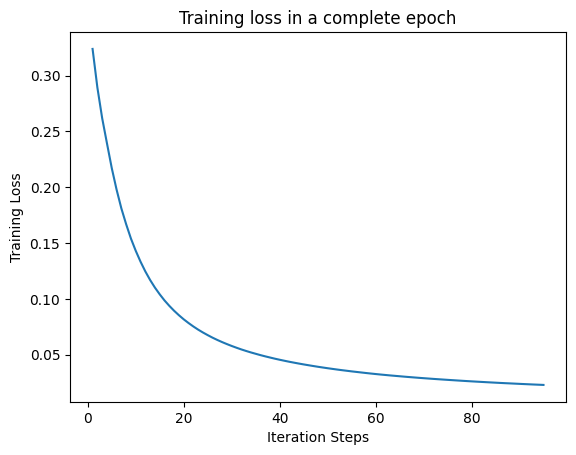

Validation Loss in epoch 1


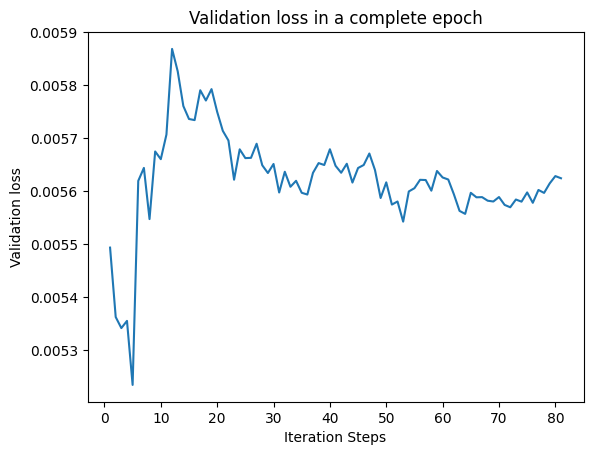


--------------------------------------------------
Epoch: 1  Train Loss: 0.0230  Valid Loss: 0.0056
--------------------------------------------------

Minimum Validation Loss of 0.0056 at epoch 1/5
Model Saved

Training Loss in epoch 2


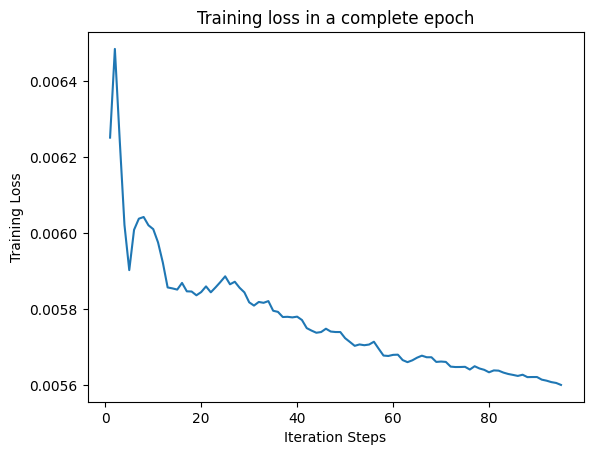

Validation Loss in epoch 2


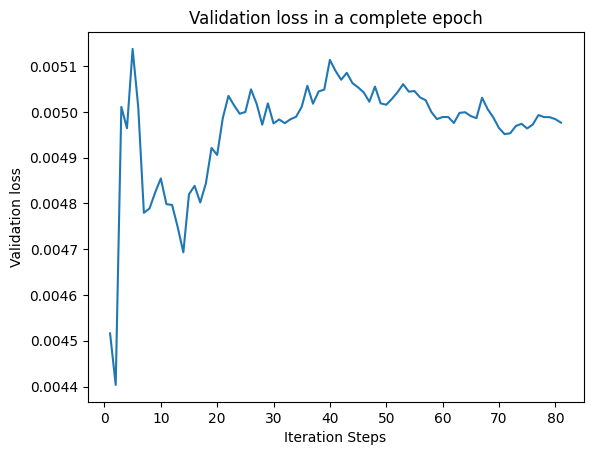


--------------------------------------------------
Epoch: 2  Train Loss: 0.0056  Valid Loss: 0.0050
--------------------------------------------------

Minimum Validation Loss of 0.0050 at epoch 2/5
Model Saved

Training Loss in epoch 3


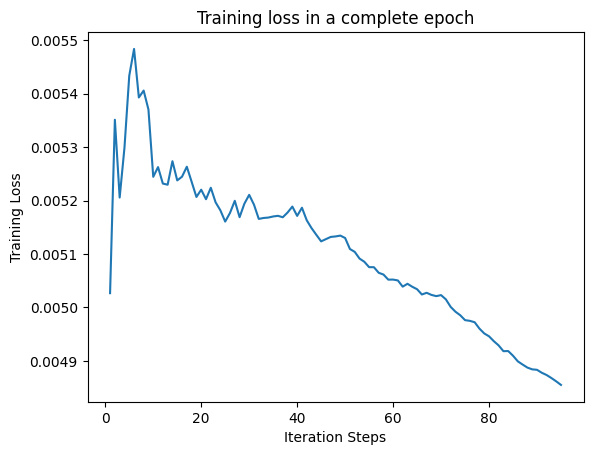

Validation Loss in epoch 3


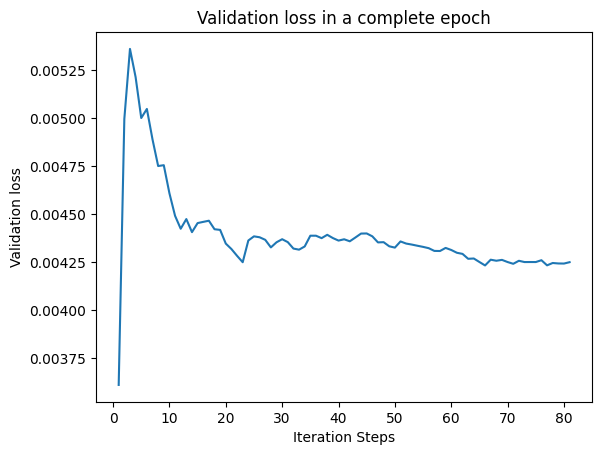


--------------------------------------------------
Epoch: 3  Train Loss: 0.0049  Valid Loss: 0.0043
--------------------------------------------------

Minimum Validation Loss of 0.0043 at epoch 3/5
Model Saved

Training Loss in epoch 4


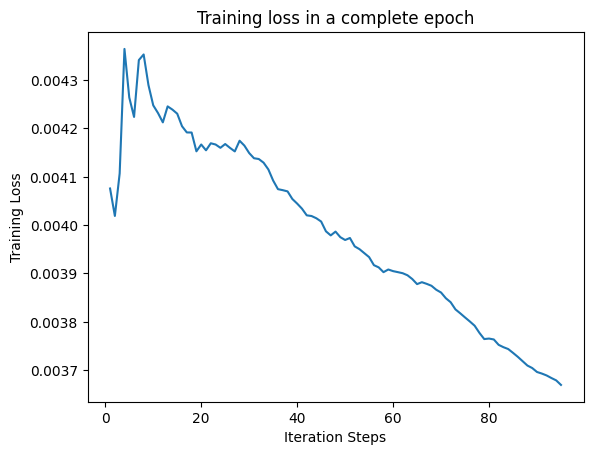

Validation Loss in epoch 4


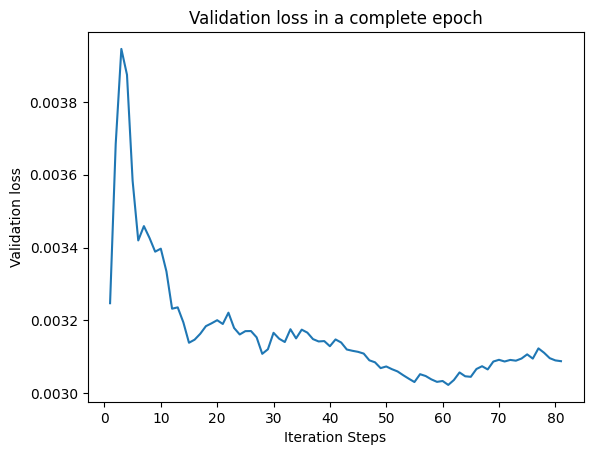


--------------------------------------------------
Epoch: 4  Train Loss: 0.0037  Valid Loss: 0.0031
--------------------------------------------------

Minimum Validation Loss of 0.0031 at epoch 4/5
Model Saved

Training Loss in epoch 5


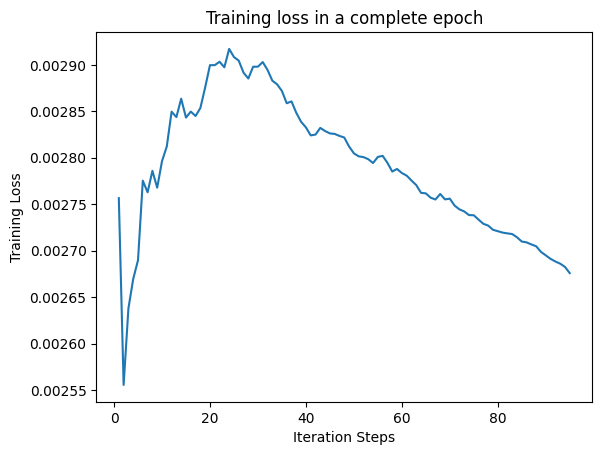

Validation Loss in epoch 5


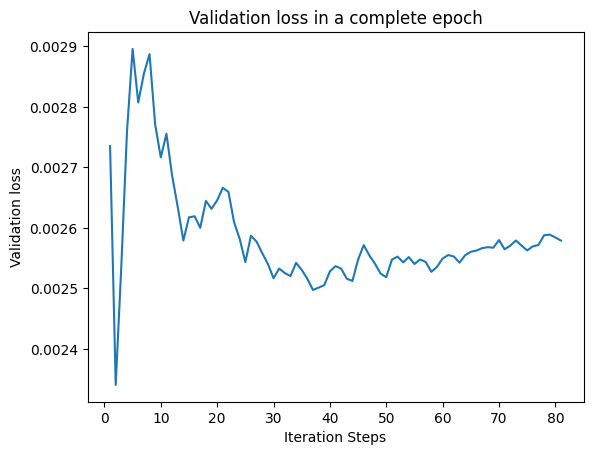


--------------------------------------------------
Epoch: 5  Train Loss: 0.0027  Valid Loss: 0.0026
--------------------------------------------------


2026/08/18 15:43:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Minimum Validation Loss of 0.0026 at epoch 5/5
Model Saved

Training Complete
Total Elapsed Time : 784.8516561985016 s


2026/08/18 15:43:47 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/08/18 15:43:48 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/08/18 15:44:00 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the loca

Model successfully saved and registered at: models:/m-03c4322bb1d54d438a096fade3aef0e3


In [6]:
# %load /content/FLD_train.py
import time
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imutils
import matplotlib.image as mpimg
from collections import OrderedDict
from skimage import io, transform
from math import *
import xml.etree.ElementTree as ET

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.pytorch
mlflow.set_experiment("Facial LandMarks Detection")

with mlflow.start_run(run_name="Best_Model") as run:
  class Network(nn.Module):
    def __init__(self,num_classes=136):
        super().__init__()
        self.model_name='resnet18'
        self.model=models.resnet18()
        self.model.conv1=nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.fc=nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        x=self.model(x)
        return x

  torch.autograd.set_detect_anomaly(True)
  network = Network()
  network.cuda()

  criterion = nn.MSELoss()
  optimizer = optim.Adam(network.parameters(), lr=0.0001)

  loss_min = np.inf
  num_epochs = 5

  start_time = time.time()
  for epoch in range(1,num_epochs+1):
    loss_train = 0
    loss_valid = 0
    running_loss = 0
    l_t = []
    l_v = []
    network.train()
    for step in range(1,len(train_loader)+1):
        images, landmarks = next(iter(train_loader))
        images = images.cuda()
        landmarks = landmarks.view(landmarks.size(0),-1).cuda()
        predictions = network(images)
        # clear all the gradients before calculating them
        optimizer.zero_grad()
        # find the loss for the current step
        loss_train_step = criterion(predictions, landmarks)
        # calculate the gradients
        loss_train_step.backward()
        # update the parameters
        optimizer.step()
        loss_train += loss_train_step.item()
        running_loss = loss_train/step
        l_t.append(running_loss)
        #print_overwrite(step, len(train_loader), running_loss, 'train')
    print("Training Loss in epoch", epoch )
    plt.plot(range(1,len(train_loader)+1), l_t)
    plt.xlabel('Iteration Steps')
    plt.ylabel('Training Loss')
    plt.title('Training loss in a complete epoch')
    plt.show()
    network.eval()
    with torch.no_grad():
        for step in range(1,len(valid_loader)+1):
          images, landmarks = next(iter(valid_loader))
          images = images.cuda()
          landmarks = landmarks.view(landmarks.size(0),-1).cuda()
          predictions = network(images)
          # find the loss for the current step
          loss_valid_step = criterion(predictions, landmarks)
          loss_valid += loss_valid_step.item()
          running_loss = loss_valid/step
          l_v.append(running_loss)
          #print_overwrite(step, len(valid_loader), running_loss, 'valid')
    print("Validation Loss in epoch", epoch )
    plt.plot(range(1,len(valid_loader)+1), l_v)
    plt.xlabel('Iteration Steps')
    plt.ylabel('Validation loss')
    plt.title('Validation loss in a complete epoch')
    plt.show()
    loss_train /= len(train_loader)
    loss_valid /= len(valid_loader)
    print('\n--------------------------------------------------')
    print('Epoch: {}  Train Loss: {:.4f}  Valid Loss: {:.4f}'.format(epoch, loss_train, loss_valid))
    print('--------------------------------------------------')
    if loss_valid < loss_min:
        loss_min = loss_valid
        torch.save(network.state_dict(), '/content/face_landmarks.pth')
        print("\nMinimum Validation Loss of {:.4f} at epoch {}/{}".format(loss_min, epoch, num_epochs))
        print('Model Saved\n')
  print('Training Complete')
  print("Total Elapsed Time : {} s".format(time.time()-start_time))

  # Save, log, and register the optimal model instance inside the MLflow Model Registry
  model_info = mlflow.pytorch.log_model(
    pytorch_model=network,
    artifact_path="best_network",
    registered_model_name="Resnet_Facial_Landmarks_Model",
    serialization_format="pickle"  # <--- Add this line
    )
  mlflow.log_metrics({
            "MSE_Validation_loss": loss_min
        }, step=epoch)
  #mlflow.log_artifact(images, artifact_path="images")
  #mlflow.log_artifact(landmarks, artifact_path="landmarks")
  #mlflow.log_artifact(predictions, artifact_path="Validation_predictions")

print(f"Model successfully saved and registered at: {model_info.model_uri}")


Loading model from registry: models:/Resnet_Facial_Landmarks_Model/1...
Total number of test images: 641
Elapsed Time : 0.3341805934906006


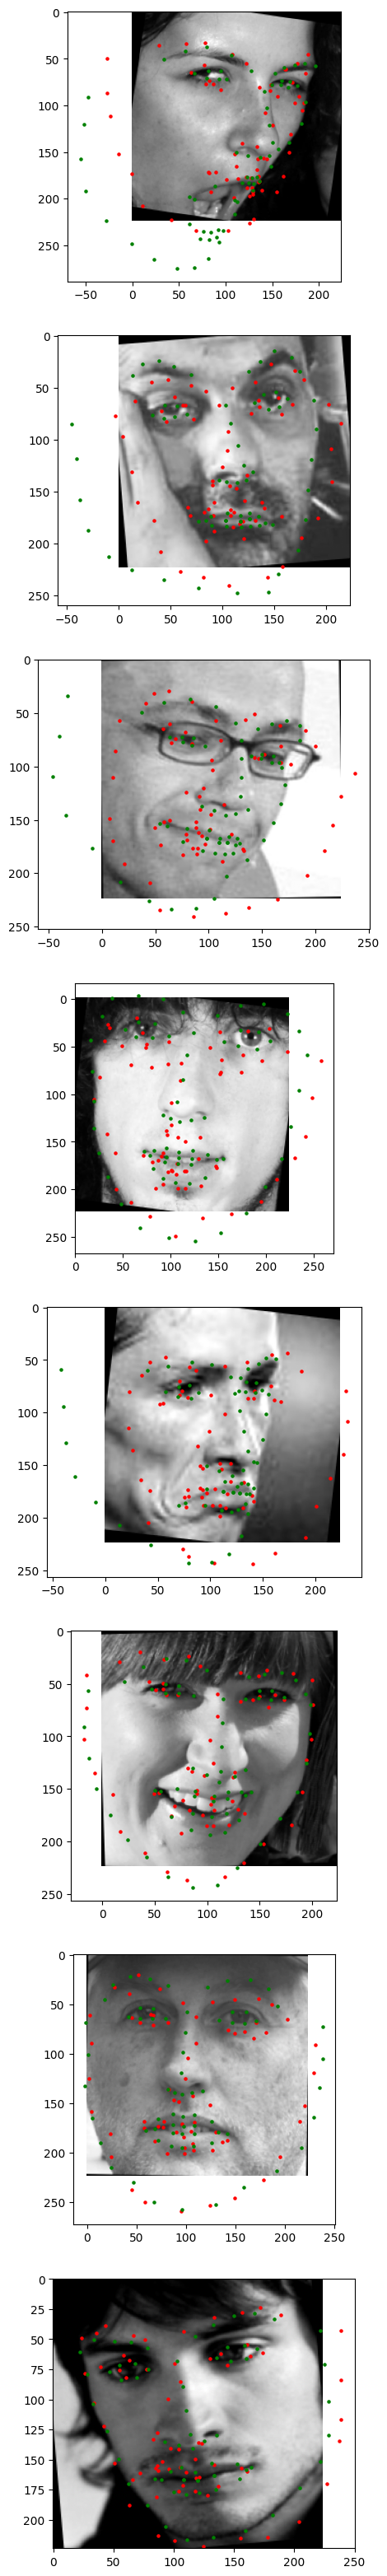

In [8]:
# %load /content/FLD_inference.py
import mlflow.pytorch
import pandas as pd

# Define constants
# TODO: Replace '123456' with your actual roll number
#ROLL_NUMBER = "da25m600"
MODEL_NAME = "Resnet_Facial_Landmarks_Model"
MODEL_VERSION = "1"  # Or use a stage like 'Production' (e.g., f"models:/{MODEL_NAME}/Production")
MODEL_URI = f"models:/{MODEL_NAME}/{MODEL_VERSION}"

#INPUT_FILE = "/content/test_processed_da25m600.parquet"
#OUTPUT_FILE = f"predictions_{ROLL_NUMBER}.csv"


def run_inference():
    print(f"Loading model from registry: {MODEL_URI}...")
    # Load the registered model as a PyFunc model
    model = mlflow.pytorch.load_model(model_uri=MODEL_URI)
    start_time = time.time()
    with torch.no_grad():
      best_network = model
      best_network.cuda()
      best_network.load_state_dict(torch.load('/content/face_landmarks.pth'))
      best_network.eval()
      images, landmarks = next(iter(valid_loader))
      images = images.cuda()
      landmarks = (landmarks + 0.5) * 224
      predictions = (best_network(images).cpu() + 0.5) * 224
      predictions = predictions.view(-1,68,2)
      plt.figure(figsize=(10,40))
      for img_num in range(8):
        plt.subplot(8,1,img_num+1)
        plt.imshow(images[img_num].cpu().numpy().transpose(1,2,0).squeeze(), cmap='gray')
        plt.scatter(predictions[img_num,:,0], predictions[img_num,:,1], c = 'r', s = 5)
        plt.scatter(landmarks[img_num,:,0], landmarks[img_num,:,1], c = 'g', s = 5)

    print('Total number of test images: {}'.format(len(valid_dataset)))
    end_time = time.time()
    print("Elapsed Time : {}".format(end_time - start_time))

if __name__ == "__main__":
    run_inference()

Starting Prometheus metrics server on port 8000...
Loading model from registry: models:/Resnet_Facial_Landmarks_Model/1...
Total number of test images: 641
Throughput: 20.36 images/sec
Elapsed Time : 0.3929331302642822


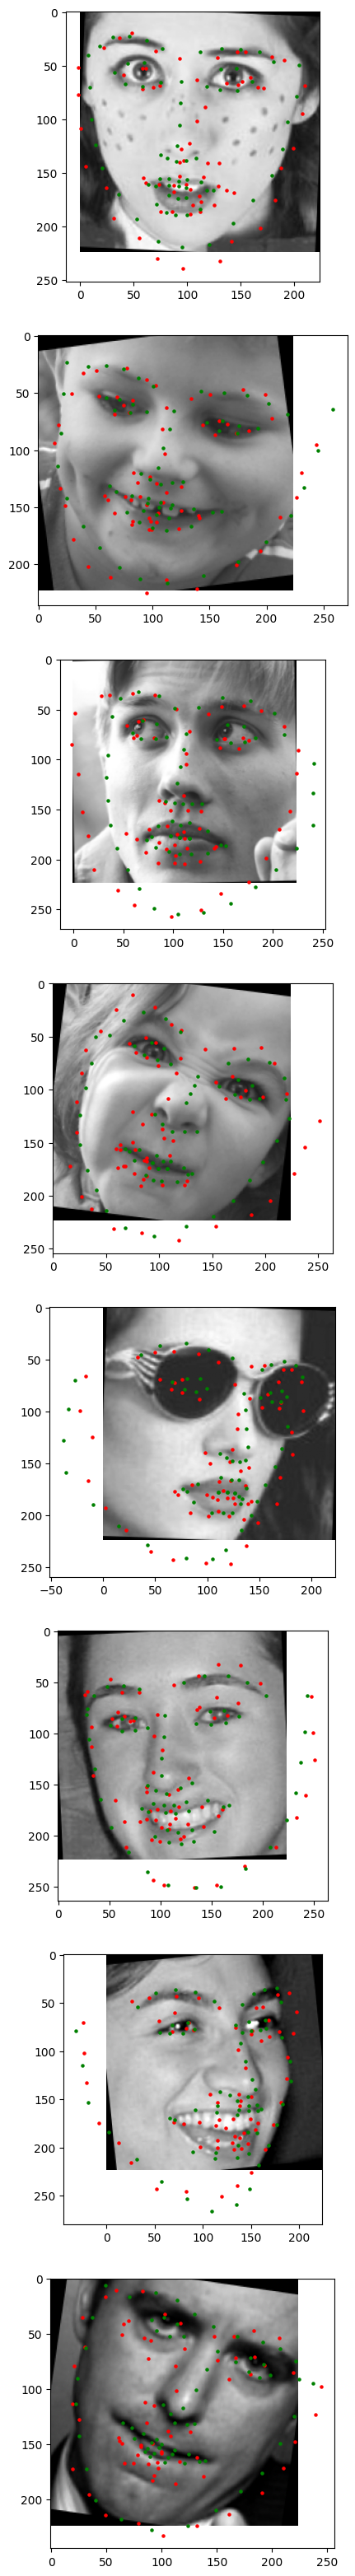

In [10]:
import time
import torch
import matplotlib.pyplot as plt
import mlflow.pytorch
import pandas as pd
from prometheus_client import start_http_server, Counter, Gauge, Summary

# --- Prometheus Metrics Definition ---
# 1. End-to-end Latency
LATENCY_GAUGE = Gauge(
    'inference_latency_seconds',
    'End-to-end latency for the inference request in seconds'
)

# 2. Request Success / Failure Tracking
REQUEST_COUNTER = Counter(
    'inference_requests_total',
    'Total number of inference requests',
    ['status']
)

# 3. Input and Output Token Counts
TOKEN_COUNTER = Counter(
    'inference_tokens_total',
    'Total number of tokens processed',
    ['type']
)

# 4. Throughput (Images per second)
THROUGHPUT_SUMMARY = Summary(
    'inference_throughput_images_per_second',
    'Number of images processed per second'
)

# Define constants
MODEL_NAME = "Resnet_Facial_Landmarks_Model"
MODEL_VERSION = "1"
MODEL_URI = f"models:/{MODEL_NAME}/{MODEL_VERSION}"


def run_inference():
    print(f"Loading model from registry: {MODEL_URI}...")

    # Track request status
    status = "failed"
    start_time = time.time()

    try:
        # Load the registered model as a PyFunc model
        model = mlflow.pytorch.load_model(model_uri=MODEL_URI)

        with torch.no_grad():
            best_network = model
            best_network.cuda()
            best_network.load_state_dict(torch.load('/content/face_landmarks.pth'))
            best_network.eval()

            # Assuming valid_loader and valid_dataset are defined globally in your notebook environment
            images, landmarks = next(iter(valid_loader))
            num_images = images.size(0)

            # --- Token Calculation Logic ---
            # For CV models, we simulate token count using image patches (e.g., 16x16 patches for a 224x224 image = 196 tokens)
            # Output tokens represent the 68 coordinates generated per image
            tokens_per_image_in = 196
            tokens_per_image_out = 68

            input_tokens = num_images * tokens_per_image_in
            output_tokens = num_images * tokens_per_image_out

            # Log tokens to Prometheus
            TOKEN_COUNTER.labels(type='input').inc(input_tokens)
            TOKEN_COUNTER.labels(type='output').inc(output_tokens)

            # Inference execution
            images = images.cuda()
            landmarks = (landmarks + 0.5) * 224
            predictions = (best_network(images).cpu() + 0.5) * 224
            predictions = predictions.view(-1, 68, 2)

            # Plotting logic
            plt.figure(figsize=(10, 40))
            for img_num in range(min(8, num_images)):
                plt.subplot(8, 1, img_num + 1)
                plt.imshow(images[img_num].cpu().numpy().transpose(1, 2, 0).squeeze(), cmap='gray')
                plt.scatter(predictions[img_num, :, 0], predictions[img_num, :, 1], c='r', s=5)
                plt.scatter(landmarks[img_num, :, 0], landmarks[img_num, :, 1], c='g', s=5)

        print('Total number of test images: {}'.format(len(valid_dataset)))
        status = "success"

    except Exception as e:
        status = "failed"
        print(f"An error occurred during inference: {e}")
        raise e

    finally:
        end_time = time.time()
        elapsed_time = end_time - start_time

        # --- Update Prometheus Metrics ---
        LATENCY_GAUGE.set(elapsed_time)
        REQUEST_COUNTER.labels(status=status).inc()

        if status == "success" and elapsed_time > 0:
            throughput = num_images / elapsed_time
            THROUGHPUT_SUMMARY.observe(throughput)
            print(f"Throughput: {throughput:.2f} images/sec")

        print("Elapsed Time : {}".format(elapsed_time))


if __name__ == "__main__":
    # Start Prometheus scraping server on port 8000
    # Keep this port open so your Prometheus server can scrape data from http://localhost:8000
    PROMETHEUS_PORT = 8000
    print(f"Starting Prometheus metrics server on port {PROMETHEUS_PORT}...")
    start_http_server(PROMETHEUS_PORT)

    # Run the inference function
    run_inference()

    # If running as a persistent background service, prevent the script from exiting instantly:
    # while True: time.sleep(1)
